In [1]:
import pandas as pd

# Create an example insurance dataset
data = {
    'age': [25, 45, 52, 37, 62],
    'gender': ['Female', 'Male', 'Male', 'Female', 'Female'],
    'bmi': [23.4, 27.8, 31.2, 22.9, 24.3],
    'children': [0, 2, 1, 3, 0],
    'smoker': ['No', 'Yes', 'No', 'Yes', 'No'],
    'region': ['southeast', 'southwest', 'northeast', 'northwest', 'southeast'],
    'charges': [3200, 16800, 9800, 14400, 3240]
}

insurance_df = pd.DataFrame(data)
display(insurance_df)


,age,gender,bmi,children,smoker,region,charges
0,25,Female,23.4,0,No,southeast,3200
1,45,Male,27.8,2,Yes,southwest,16800
2,52,Male,31.2,1,No,northeast,9800
3,37,Female,22.9,3,Yes,northwest,14400
4,62,Female,24.3,0,No,southeast,3240


In [2]:
# Basic info
print(insurance_df.info())

# Descriptive statistics
print(insurance_df.describe(include='all'))

# Check for nulls
print(insurance_df.isnull().sum())

# Value counts for categorical variables
print("Gender distribution:")
print(insurance_df['gender'].value_counts())

print("\nSmoker distribution:")
print(insurance_df['smoker'].value_counts())

# Display correlations
print("\nCorrelation matrix:")
print(insurance_df.corr(numeric_only=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5 non-null      int64  
 1   gender    5 non-null      object 
 2   bmi       5 non-null      float64
 3   children  5 non-null      int64  
 4   smoker    5 non-null      object 
 5   region    5 non-null      object 
 6   charges   5 non-null      int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 412.0+ bytes
None
              age  gender        bmi  children smoker     region       charges
count    5.000000       5   5.000000   5.00000      5          5      5.000000
unique        NaN       2        NaN       NaN      2          4           NaN
top           NaN  Female        NaN       NaN     No  southeast           NaN
freq          NaN       3        NaN       NaN      3          2           NaN
mean    44.200000     NaN  25.920000   1.20000    NaN        NaN   9488.000000
std

In [3]:
# Example: Drop duplicates
insurance_df = insurance_df.drop_duplicates()

# Handle possible missing values
insurance_df = insurance_df.fillna({
    'age': insurance_df['age'].median(),
    'bmi': insurance_df['bmi'].mean(),
    'charges': insurance_df['charges'].mean(),
    'children': 0,  # default to 0 if unknown
    'gender': insurance_df['gender'].mode()[0],
    'smoker': 'No',
    'region': insurance_df['region'].mode()[0]
})

# Standardize categorical values
insurance_df['gender'] = insurance_df['gender'].str.title()
insurance_df['smoker'] = insurance_df['smoker'].str.title()
insurance_df['region'] = insurance_df['region'].str.lower()

display(insurance_df)


,age,gender,bmi,children,smoker,region,charges
0,25,Female,23.4,0,No,southeast,3200
1,45,Male,27.8,2,Yes,southwest,16800
2,52,Male,31.2,1,No,northeast,9800
3,37,Female,22.9,3,Yes,northwest,14400
4,62,Female,24.3,0,No,southeast,3240


C:\Users\hp\AppData\Local\Temp\ipykernel_12300\3297661959.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=insurance_df, x='smoker', y='charges', ci=None)


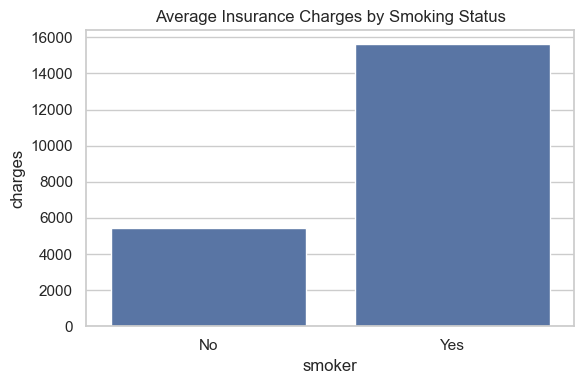

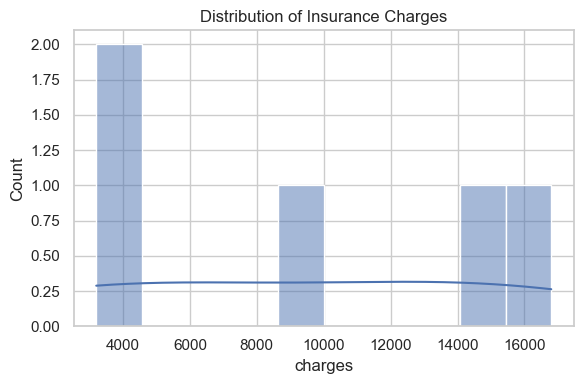

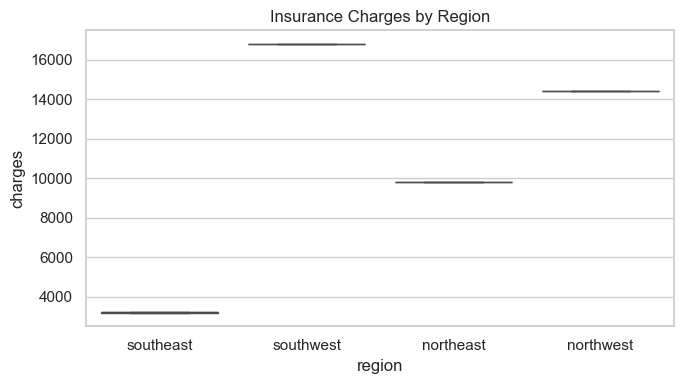

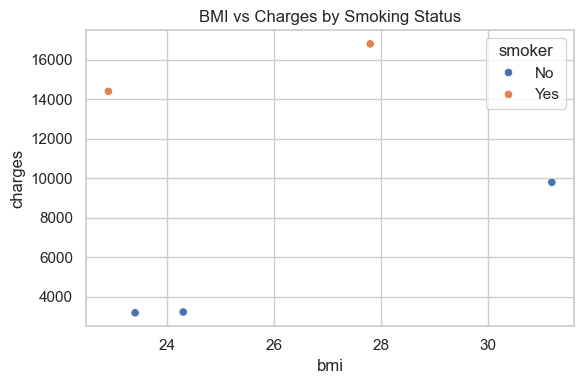

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Average charges by smoking status
plt.figure(figsize=(6, 4))
sns.barplot(data=insurance_df, x='smoker', y='charges', ci=None)
plt.title('Average Insurance Charges by Smoking Status')
plt.tight_layout()
plt.show()

# Distribution of Charges
plt.figure(figsize=(6, 4))
sns.histplot(insurance_df['charges'], bins=10, kde=True)
plt.title('Distribution of Insurance Charges')
plt.tight_layout()
plt.show()

# Charges by Region
plt.figure(figsize=(7, 4))
sns.boxplot(data=insurance_df, x='region', y='charges')
plt.title('Insurance Charges by Region')
plt.tight_layout()
plt.show()

# Correlation: BMI vs Charges
plt.figure(figsize=(6, 4))
sns.scatterplot(data=insurance_df, x='bmi', y='charges', hue='smoker')
plt.title('BMI vs Charges by Smoking Status')
plt.tight_layout()
plt.show()

In [5]:
from reportlab.platypus import SimpleDocTemplate, Image, Paragraph
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet

# Save previous plots as images
plt.figure(figsize=(6,4))
sns.barplot(data=insurance_df, x='smoker', y='charges', errorbar=None)
plt.title('Average Insurance Charges by Smoking Status')
plt.tight_layout()
plt.savefig('charges_by_smoker.png')
plt.close()

plt.figure(figsize=(6,4))
sns.histplot(insurance_df['charges'], bins=10, kde=True)
plt.title('Distribution of Insurance Charges')
plt.tight_layout()
plt.savefig('charges_distribution.png')
plt.close()

doc = SimpleDocTemplate("Insurance_Report.pdf", pagesize=letter)
styles = getSampleStyleSheet()
story = []

story.append(Paragraph("Insurance Data Report", styles['Heading1']))
story.append(Paragraph("Average Insurance Charges by Smoking Status", styles['Heading2']))
story.append(Image("charges_by_smoker.png", width=400, height=250))
story.append(Paragraph("Distribution of Insurance Charges", styles['Heading2']))
story.append(Image("charges_distribution.png", width=400, height=250))

doc.build(story)


In [6]:
from reportlab.platypus import SimpleDocTemplate, Image, Paragraph
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Make sure we know where files are going
BASE_DIR = os.getcwd()

# -------------------------
# 1. Charges by smoker
# -------------------------
plt.figure(figsize=(6,4))
sns.barplot(data=insurance_df, x="smoker", y="charges", errorbar=None)
plt.title("Average Insurance Charges by Smoking Status")
plt.tight_layout()
plt.draw()
plt.savefig("charges_by_smoker.png", dpi=150)
plt.close()

# -------------------------
# 2. Distribution of charges
# -------------------------
plt.figure(figsize=(6,4))
sns.histplot(insurance_df["charges"], bins=10, kde=False)
plt.title("Distribution of Insurance Charges")
plt.tight_layout()
plt.draw()
plt.savefig("charges_distribution.png", dpi=150)
plt.close()

# -------------------------
# 3. Charges by region
# -------------------------
plt.figure(figsize=(7,4))
sns.boxplot(data=insurance_df, x="region", y="charges")
plt.title("Insurance Charges by Region")
plt.tight_layout()
plt.draw()
plt.savefig("boxplot_by_region.png", dpi=150)
plt.close()

# -------------------------
# 4. BMI vs charges
# -------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=insurance_df,
    x="bmi",
    y="charges",
    hue="smoker"
)
plt.title("BMI vs Charges by Smoking Status")
plt.tight_layout()
plt.draw()
plt.savefig("bmi_vs_charges.png", dpi=150)
plt.close()

# -------------------------
# Validate files exist
# -------------------------
images = [
    "charges_by_smoker.png",
    "charges_distribution.png",
    "boxplot_by_region.png",
    "bmi_vs_charges.png"
]

for img in images:
    path = os.path.join(BASE_DIR, img)
    assert os.path.exists(path), f"Missing file: {img}"

# -------------------------
# Build PDF
# -------------------------
doc = SimpleDocTemplate(
    "Insurance_Report.pdf",
    pagesize=letter
)

styles = getSampleStyleSheet()
story = []

# Title
story.append(Paragraph("Insurance Data Report", styles["Heading1"]))

# Chart 1
story.append(Paragraph("Average Insurance Charges by Smoking Status", styles["Heading2"]))
story.append(Image(os.path.join(BASE_DIR, "charges_by_smoker.png"), width=400, height=250))

# Chart 2
story.append(Paragraph("Distribution of Insurance Charges", styles["Heading2"]))
story.append(Image(os.path.join(BASE_DIR, "charges_distribution.png"), width=400, height=250))

# Chart 3
story.append(Paragraph("Insurance Charges by Region", styles["Heading2"]))
story.append(Image(os.path.join(BASE_DIR, "boxplot_by_region.png"), width=400, height=250))

# Chart 4
story.append(Paragraph("BMI vs Charges by Smoking Status", styles["Heading2"]))
story.append(Image(os.path.join(BASE_DIR, "bmi_vs_charges.png"), width=400, height=250))

doc.build(story)


In [7]:
from IPython.display import FileLink

# Display clickable link to open/download the PDF in notebook
display(FileLink('Insurance_Report.pdf'))


C:\Users\hp\Downloads\Insurance_Report.pdf